# *Data Loading*




In [ ]:
# prompt: how to load data from this path /content/drive/MyDrive/shareables/EURUSD-Minute5.csv from drive into colab?

from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
#df = pd.read_csv('/content/drive/MyDrive/shareables/EURUSD-Minute5.csv')
df = pd.read_csv('/content/drive/MyDrive/shareables/EURUSD-Hour.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_csv('EURUSD-Hour.csv')


: 

In [ ]:


print(df.head())
print(df.info())
print(df.columns)


   2022.11.25  00:00  1.04076  1.04113  1.03961  1.04057  4549  37503
0  2022.11.25  01:00  1.04059  1.04151  1.04034  1.04093  5534  43041
1  2022.11.25  02:00  1.04091  1.04155  1.04082  1.04110  3993  47034
2  2022.11.25  03:00  1.04110  1.04183  1.04045  1.04162  3562  50596
3  2022.11.25  04:00  1.04162  1.04292  1.04161  1.04213  4509  55105
4  2022.11.25  05:00  1.04214  1.04222  1.04073  1.04112  4041  51060
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10438 entries, 0 to 10437
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   2022.11.25  10438 non-null  object 
 1   00:00       10438 non-null  object 
 2   1.04076     10438 non-null  float64
 3   1.04113     10438 non-null  float64
 4   1.03961     10438 non-null  float64
 5   1.04057     10438 non-null  float64
 6   4549        10438 non-null  int64  
 7   37503       10438 non-null  int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 652.5+ K

In [ ]:
# Rename columns for clarity
df.columns = [ 'Date', 'Time', 'Open', 'High', 'Low', 'Close', 'TickVolume', 'Bar Volume']


# Combine date and time columns
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df.set_index('Datetime', inplace=True)
df.drop(columns=['Date', 'Time'], inplace=True)


# Ensure the data is sorted by datetime
df.sort_index(inplace=True)

# Display the updated DataFrame
print(df.head())


                        Open     High      Low    Close  TickVolume  \
Datetime                                                              
2022-11-25 01:00:00  1.04059  1.04151  1.04034  1.04093        5534   
2022-11-25 02:00:00  1.04091  1.04155  1.04082  1.04110        3993   
2022-11-25 03:00:00  1.04110  1.04183  1.04045  1.04162        3562   
2022-11-25 04:00:00  1.04162  1.04292  1.04161  1.04213        4509   
2022-11-25 05:00:00  1.04214  1.04222  1.04073  1.04112        4041   

                     Bar Volume  
Datetime                         
2022-11-25 01:00:00       43041  
2022-11-25 02:00:00       47034  
2022-11-25 03:00:00       50596  
2022-11-25 04:00:00       55105  
2022-11-25 05:00:00       51060  


# **Indicators**

In [ ]:
!pip install -q ta
!pip install -q stable-baselines3
!pip install -q 'shimmy>=0.2.1'
!pip install -q 'gymnasium<0.30'

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 958.1/958.1 kB 41.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
stable-baselines3 2.3.2 requires gymnasium<0.30,>=0.28.1, but you have gymnasium 1.0.0 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shimmy 2.0.0 requires gymnasium>=1.0.0a1, but you have gymnasium 0.29.1 which is incompatible.


In [ ]:
import ta

def add_indicators_with_crossovers(data):
    # Adding EMA
    data['EMA_4'] = ta.trend.EMAIndicator(data['Close'], window=144).ema_indicator()
    data['EMA_1'] = ta.trend.EMAIndicator(data['Close'], window=21).ema_indicator()
    data['EMA_2'] = ta.trend.EMAIndicator(data['Close'], window=55).ema_indicator()
    data['EMA_3'] = ta.trend.EMAIndicator(data['Close'], window=89).ema_indicator()

    # Adding SMA
    data['SMA_1'] = ta.trend.SMAIndicator(data['Close'], window=50).sma_indicator()
    data['SMA_2'] = ta.trend.SMAIndicator(data['Close'], window=200).sma_indicator()

    # Adding RSI
    data['RSI'] = ta.momentum.RSIIndicator(data['Close'], window=9).rsi()

    # Adding MACD
    macd = ta.trend.MACD(data['Close'], window_slow=26, window_fast=12, window_sign=9)
    data['MACD'] = macd.macd()
    data['MACD_Signal'] = macd.macd_signal()

    # Adding EMA Crossovers
    data['Fast_EMA'] = ta.trend.EMAIndicator(data['Close'], window=13).ema_indicator()
    data['Slow_EMA'] = ta.trend.EMAIndicator(data['Close'], window=48).ema_indicator()
    data['EMA_Crossover'] = data['Fast_EMA'] > data['Slow_EMA']

    return data

df = add_indicators_with_crossovers(df)

In [ ]:
!pip install ta
!pip install stable-baselines3
!pip install 'shimmy>=0.2.1'
!pip install 'gymnasium<0.30'

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=3c3d6f801c953e6c31e2b464175a53503bf7e6f6b52da835994aa10715be57f7
  Stored in directory: /root/.cache/pip/wheels/5f/67/4f/8a9f252836e053e532c6587a3230bc72a4deb16b03a829610b
Successfully built ta
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolv

In [ ]:
import ta

def add_indicators_with_crossovers(data):
    # Adding EMA
    data['EMA_4'] = ta.trend.EMAIndicator(data['Close'], window=144).ema_indicator()
    data['EMA_1'] = ta.trend.EMAIndicator(data['Close'], window=21).ema_indicator()
    data['EMA_2'] = ta.trend.EMAIndicator(data['Close'], window=55).ema_indicator()
    data['EMA_3'] = ta.trend.EMAIndicator(data['Close'], window=89).ema_indicator()

    # Adding SMA
    data['SMA_1'] = ta.trend.SMAIndicator(data['Close'], window=50).sma_indicator()
    data['SMA_2'] = ta.trend.SMAIndicator(data['Close'], window=200).sma_indicator()

    # Adding RSI
    data['RSI'] = ta.momentum.RSIIndicator(data['Close'], window=9).rsi()

    # Adding MACD
    macd = ta.trend.MACD(data['Close'], window_slow=26, window_fast=12, window_sign=9)
    data['MACD'] = macd.macd()
    data['MACD_Signal'] = macd.macd_signal()

    # Adding EMA Crossovers
    data['Fast_EMA'] = ta.trend.EMAIndicator(data['Close'], window=13).ema_indicator()
    data['Slow_EMA'] = ta.trend.EMAIndicator(data['Close'], window=48).ema_indicator()
    data['EMA_Crossover'] = data['Fast_EMA'] > data['Slow_EMA']

    # Adding Parabolic SAR
    data['Parabolic_SAR'] = ta.trend.PSARIndicator(data['High'], data['Low'], data['Close']).psar()

    # Adding ADX
    data['ADX'] = ta.trend.ADXIndicator(data['High'], data['Low'], data['Close'], window=14).adx()

    # Adding SuperTrend
    def supertrend(data, period, multiplier):
        st = ta.trend.STCIndicator(close=data['Close'], fillna=True, window_slow=period, window_fast=period//3).stc()
        data[f'SuperTrend_{period}_{multiplier}'] = st

    supertrend(data, period=7, multiplier=3)
    supertrend(data, period=10, multiplier=3)
    supertrend(data, period=20, multiplier=3)

    # Adding Bollinger Bands
    bb = ta.volatility.BollingerBands(close=data['Close'], window=20, window_dev=2)
    data['BB_High'] = bb.bollinger_hband()
    data['BB_Mid'] = bb.bollinger_mavg()
    data['BB_Low'] = bb.bollinger_lband()

    return data

df = add_indicators_with_crossovers(df)


/usr/local/lib/python3.10/dist-packages/ta/trend.py:1030: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  self._psar[i] = high2


In [ ]:
df.head(60)

,Open,High,Low,Close,TickVolume,Bar Volume,EMA_4,EMA_1,EMA_2,EMA_3,...,Slow_EMA,EMA_Crossover,Parabolic_SAR,ADX,SuperTrend_7_3,SuperTrend_10_3,SuperTrend_20_3,BB_High,BB_Mid,BB_Low
Datetime,,,,,,,,,,,,,,,,,,,,,
2022-11-25 01:00:00,1.04059,1.04151,1.04034,1.04093,5534,43041,NaN,NaN,NaN,NaN,...,NaN,False,1.040930,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
2022-11-25 02:00:00,1.04091,1.04155,1.04082,1.04110,3993,47034,NaN,NaN,NaN,NaN,...,NaN,False,1.041100,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
2022-11-25 03:00:00,1.04110,1.04183,1.04045,1.04162,3562,50596,NaN,NaN,NaN,NaN,...,NaN,False,1.041510,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
2022-11-25 04:00:00,1.04162,1.04292,1.04161,1.04213,4509,55105,NaN,NaN,NaN,NaN,...,NaN,False,1.040450,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
2022-11-25 05:00:00,1.04214,1.04222,1.04073,1.04112,4041,51060,NaN,NaN,NaN,NaN,...,NaN,False,1.040450,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
2022-11-25 06:00:00,1.04110,1.04232,1.04071,1.04199,4691,55755,NaN,NaN,NaN,NaN,...,NaN,False,1.040499,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
2022-11-25 07:00:00,1.04201,1.04224,1.04086,1.04092,7058,48693,NaN,NaN,NaN,NaN,...,NaN,False,1.040548,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
2022-11-25 08:00:00,1.04090,1.04277,1.04078,1.04227,9478,58175,NaN,NaN,NaN,NaN,...,NaN,False,1.040595,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
2022-11-25 09:00:00,1.04225,1.04283,1.03825,1.03934,9787,48384,NaN,NaN,NaN,NaN,...,NaN,False,1.042920,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN


## Logger for Callbacks and Losses

In [ ]:

from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback


# Custom Callback for logging
class CustomLoggerCallback(BaseCallback):
    def __init__(self, verbose=0):
        super(CustomLoggerCallback, self).__init__(verbose)
        self.losses = []
        self.rewards = []
        self.episode_lengths = []

    def _on_step(self) -> bool:
        if self.locals['infos']:
            info = self.locals['infos'][0]
            if 'episode' in info.keys():
                self.episode_lengths.append(info['episode']['length'])
                self.rewards.append(info['episode']['r'])
        return True

    def _on_rollout_end(self) -> None:
        if self.locals.get('infos'):
            self.losses.append(self.locals.get('logger').get_stats('train/loss'))

    def get_logs(self):
        return {
            "losses": self.losses,
            "rewards": self.rewards,
            "episode_lengths": self.episode_lengths
        }




# Trading Training Environment with Test

In [ ]:
import pandas as pd
import numpy as np
import gym
from gym import spaces

class TradingEnv(gym.Env):
    def __init__(self, data):
        super(TradingEnv, self).__init__()

        self.data = data.reset_index(drop=True)  # Ensure DataFrame index is reset
        self.current_step = 0
        self.max_steps = len(data) - 1  # Adjust max_steps for zero-based indexing
        self.done = False

        # Define action and observation space
        self.action_space = spaces.Discrete(3)  # 0: Hold, 1: Buy, 2: Sell
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(len(data.columns),), dtype=np.float32)

        self.current_position = 0
        self.current_balance = 10000  # Starting balance
        self.last_trade_price = 0

    def reset(self):
        self.current_step = 0
        self.done = False
        self.current_position = 0
        self.current_balance = 10000
        self.last_trade_price = 0
        return self.data.iloc[self.current_step].values.astype(np.float32)  # Ensure dtype is float32

    def step(self, action):
        if self.done:
            raise RuntimeError("Environment is done, call reset() to start a new episode.")

        # Ensure the current step does not exceed the DataFrame length
        if self.current_step > self.max_steps:
            self.done = True
            return self.data.iloc[self.current_step].values.astype(np.float32), 0, self.done, {}

        current_price = self.data.iloc[self.current_step]['Close']
        reward = 0

        if action == 1:  # Buy
            if self.current_position == 0:  # No current position
                self.current_position = self.current_balance / current_price
                self.current_balance = 0
                self.last_trade_price = current_price

        elif action == 2:  # Sell 0

            if self.current_position > 0:  # Currently holding a position
                self.current_balance = self.current_position * current_price
                reward = self.current_balance - 10000  # Profit or loss
                self.current_position = 0

        self.current_step += 1

        if self.current_step > self.max_steps:  # Check boundary after step increment
            self.done = True

        # Return next state and other info
        next_state = self.data.iloc[self.current_step].values.astype(np.float32) if not self.done else self.data.iloc[self.max_steps].values.astype(np.float32)
        return next_state, reward, self.done, {}

    def render(self, mode='human'):
        print(f"Step: {self.current_step}, Balance: {self.current_balance}, Position: {self.current_position}")


env = TradingEnv(df)

state = env.reset()
done = False
while not done:
    action = env.action_space.sample()  # Random action
    next_state, reward, done, _ = env.step(action)
    env.render()


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Streaming output truncated to the last 5000 lines.
Step: 5439, Balance: 9742.701297789294, Position: 0
Step: 5440, Balance: 0, Position: 9176.42416270855
Step: 5441, Balance: 0, Position: 9176.42416270855
Step: 5442, Balance: 0, Position: 9176.42416270855
Step: 5443, Balance: 0, Position: 9176.42416270855
Step: 5444, Balance: 0, Position: 9176.42416270855
Step: 5445, Balance: 0, Position: 9176.42416270855
Step: 5446, Balance: 9731.322531827536, Position: 0
Step: 5447, Balance: 0, Position: 9175.905002053252
Step: 5448, Balance: 9730.40494132733, Position: 0
Step: 5449, Balance: 0, Position: 9170.456846292698
Step: 5450, Balance: 0, Position: 9170.456846292698
Step: 5451, Balance: 0, Position: 9170.456846292698
Step: 5452, Balance: 9725.086076356481, Position: 0
Step: 5453, Balance: 9725.086076356481, Position: 0
Step: 5454, Balance: 9725.086076356481, Position: 0
Step: 5455, Balance: 9725.086076356481, Position: 0
Step: 5456, Balance: 9725.086076356481, Position: 0
Step: 5457, Balance:

In [ ]:
# Install necessary libraries
!pip install stable-baselines3[extra] gym pandas matplotlib

# Verify CUDA installation
!nvcc --version

# Verify that TensorFlow can see the GPU
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

# Verify that PyTorch can see the GPU
import torch
print("Is CUDA available: ", torch.cuda.is_available())
print("CUDA device count: ", torch.cuda.device_count())
print("Current CUDA device: ", torch.cuda.current_device())
print("CUDA device name: ", torch.cuda.get_device_name(torch.cuda.current_device()))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.7/434.7 kB 30.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 79.4 MB/s eta 0:00:00
  Created wheel for AutoROM.accept-rom-license: filename=AutoROM.accept_rom_license-0.6.1-py3-none-any.whl size=446660 sha256=02cb813a09c59e855daedc9fc27799afed37680fa2a2c79756b01e7194ff5651
  Stored in directory: /root/.cache/pip/wheels/6b/1b/ef/a43ff1a2f1736d5711faa1ba4c1f61be1131b8899e6a057811
Successfully built AutoROM.accept-rom-license
  Attempting uninstall: shimmy
    Found existing installation: Shimmy 2.0.0
    Uninstalling Shimmy-2.0.0:
      Successfully uninstalled Shimmy-2.0.0
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2023 NVIDIA Corporation
Built on Tue_Aug_15_22:02:13_PDT_2023
Cuda compilation tools, release 12.2, V12.2.140
Build cuda_12.2.r12.2/compiler.33191640_0


In [ ]:
import pandas as pd
import numpy as np
import gym
from gym import spaces
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback
import matplotlib.pyplot as plt

class TradingEnv(gym.Env):
    def __init__(self, df, initial_balance=10000, transaction_cost=0.001):
        super(TradingEnv, self).__init__()
        self.df = df
        self.current_step = 0
        self.total_steps = len(df) - 1
        self.done = False
        self.initial_balance = initial_balance
        self.current_balance = initial_balance
        self.transaction_cost = transaction_cost
        self.equity_curve = []  # Record equity curve
        self.net_worth = initial_balance
        self.position = 0
        self.position_value = 0
        self.episode_rewards = 0
        self.episode_length = 0
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.df.shape[1],), dtype=np.float32)
        self.action_space = spaces.Discrete(3)  # 0 = sell, 1 = hold, 2 = buy
        self.actions = []  # Record actions

    def step(self, action):
        self.episode_length += 1
        self.current_step += 1

        if self.current_step > self.total_steps:
            self.current_step = self.total_steps
            self.done = True

        current_price = self.df.iloc[self.current_step]['Close']
        reward = 0

        if action == 0:  # Sell
            if self.position > 0:
                sell_value = self.position * current_price
                transaction_fee = sell_value * self.transaction_cost
                self.current_balance += sell_value - transaction_fee  # Subtract transaction fee
                self.position = 0
                reward = self.current_balance - self.initial_balance  # Immediate reward for selling

        elif action == 2:  # Buy
            if self.position == 0:
                buy_value = self.current_balance
                transaction_fee = buy_value * self.transaction_cost
                self.position = (buy_value - transaction_fee) / current_price  # Subtract transaction fee
                self.current_balance = 0

        self.net_worth = self.current_balance + self.position * current_price
        self.equity_curve.append(self.net_worth)  # Record equity curve

        # Calculate Sharpe Ratio (assuming risk-free rate is 0 for simplicity)
        if self.episode_length > 1:
            returns = (self.net_worth - self.initial_balance) / self.initial_balance
            std_dev = np.std(self.equity_curve)
            if std_dev != 0:
                sharpe_ratio = returns / std_dev
            else:
                sharpe_ratio = 0

        obs = self.df.iloc[self.current_step].values
        info = {'episode': {
            'r': self.episode_rewards,
            'length': self.episode_length
        }} if self.done else {}

        return obs, reward, self.done, info

    def reset(self):
        self.current_step = 0
        self.current_balance = self.initial_balance
        self.net_worth = self.initial_balance
        self.position = 0
        self.position_value = 0
        self.episode_rewards = 0
        self.episode_length = 0
        self.done = False
        self.actions = []  # Reset actions
        self.equity_curve = []  # Reset equity curve
        return self.df.iloc[self.current_step].values




class CustomLoggerCallback(BaseCallback):
    def __init__(self, verbose=0):
        super(CustomLoggerCallback, self).__init__(verbose)
        self.rewards = []
        self.episode_lengths = []

    def _on_step(self) -> bool:
        if self.locals['infos']:
            info = self.locals['infos'][0]
            if 'episode' in info.keys():
                self.episode_lengths.append(info['episode'].get('length', 0))
                self.rewards.append(info['episode'].get('r', 0))
        return True

    def get_logs(self):
        return {
            "rewards": self.rewards,
            "episode_lengths": self.episode_lengths
        }


# Remove rows with NaNs
df.dropna(inplace=True)

# Check if any NaNs remain
print(df.isna().sum())

env = TradingEnv(df)


# Initialize the RL agent
model = DQN('MlpPolicy', env, verbose=1, device='cpu')

# Initialize the custom logger callback
logger_callback = CustomLoggerCallback()

# Train the model with the callback
model.learn(total_timesteps=10000000, callback=logger_callback)

# Save the model
model.save("dqn_trading_model")

# Retrieve the logged data
logs = logger_callback.get_logs()

# Plotting results
plt.figure(figsize=(14, 10))

# Plot rewards
plt.subplot(2, 1, 1)
plt.plot(logs["rewards"], label='Rewards')
plt.title('Episode Rewards')
plt.xlabel('Episodes')
plt.ylabel('Reward')

# Plot episode lengths
plt.subplot(2, 1, 2)
plt.plot(logs["episode_lengths"], label='Episode Lengths')
plt.title('Episode Lengths')
plt.xlabel('Episodes')
plt.ylabel('Length')

plt.tight_layout()
plt.show()


Open               0
High               0
Low                0
Close              0
TickVolume         0
Bar Volume         0
EMA_4              0
EMA_1              0
EMA_2              0
EMA_3              0
SMA_1              0
SMA_2              0
RSI                0
MACD               0
MACD_Signal        0
Fast_EMA           0
Slow_EMA           0
EMA_Crossover      0
Parabolic_SAR      0
ADX                0
SuperTrend_7_3     0
SuperTrend_10_3    0
SuperTrend_20_3    0
BB_High            0
BB_Mid             0
BB_Low             0
dtype: int64
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 1.02e+04  |
|    ep_rew_mean      | -1.23e+07 |
|    exploration_rate | 0.961     |
| time/               |           |
|    episodes         | 4         |
|    fps              | 751       |
|    time_elapsed     | 54        |
|    total_timesteps  | 40956     |
| train/              |           |
|    learning_rate    | 0.0001    |
|    loss             | 1.65e+03  |
|    n_updates        | 10213     |
-----------------------------------


KeyboardInterrupt: 

Streaming output truncated to the last 5000 lines.
| time/               |           |
|    episodes         | 11316     |
|    fps              | 505       |
|    time_elapsed     | 2788      |
|    total_timesteps  | 1409533   |
| train/              |           |
|    learning_rate    | 0.0001    |
|    loss             | 72.5      |
|    n_updates        | 352358    |
-----------------------------------
Eval num_timesteps=1410000, episode_reward=-5460.95 +/- 0.00
Episode length: 122.00 +/- 0.00
-----------------------------------
| eval/               |           |
|    mean_ep_length   | 122       |
|    mean_reward      | -5.46e+03 |
| rollout/            |           |
|    exploration_rate | 0.05      |
| time/               |           |
|    total_timesteps  | 1410000   |
| train/              |           |
|    learning_rate    | 0.0001    |
|    loss             | 48.9      |
|    n_updates        | 352474    |
-----------------------------------
----------------------------

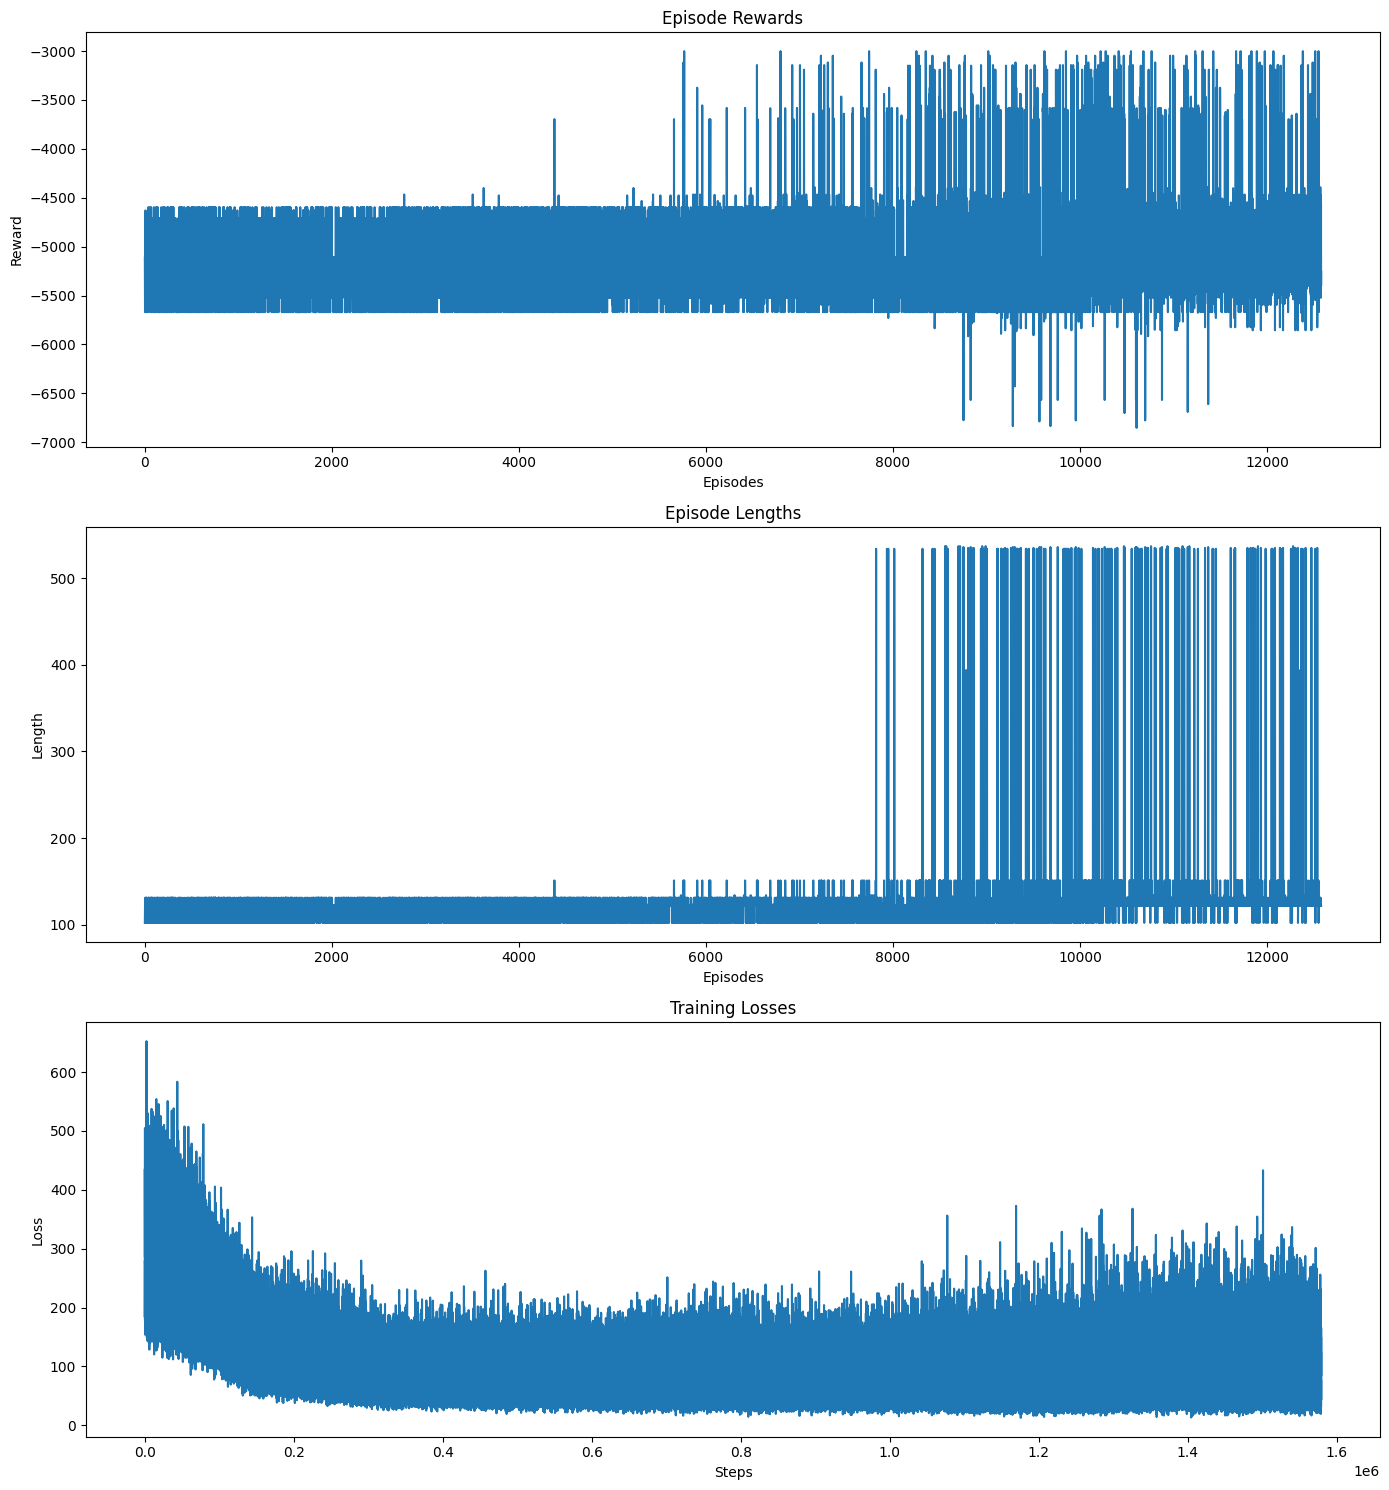

In [ ]:
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback
from stable_baselines3.common.monitor import Monitor
import matplotlib.pyplot as plt
import os

class TradingEnv(gym.Env):
    def __init__(self, df, initial_balance=10000, transaction_cost=0.001):
        super(TradingEnv, self).__init__()

        # Normalize the dataframe
        self.df = (df - df.mean()) / df.std()

        self.initial_balance = initial_balance
        self.transaction_cost = transaction_cost

        self.current_step = 0
        self.total_steps = len(df) - 1

        self.current_balance = initial_balance
        self.net_worth = initial_balance
        self.position = 0

        self.equity_curve = []
        self.episode_length = 0

        # Define action and observation space
        self.action_space = spaces.Discrete(3)  # 0 = sell, 1 = hold, 2 = buy
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.df.shape[1],), dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.current_balance = self.initial_balance
        self.net_worth = self.initial_balance
        self.position = 0
        self.equity_curve = []
        self.episode_length = 0

        return self.df.iloc[self.current_step].values, {}

    def step(self, action):
        self.episode_length += 1
        self.current_step += 1

        if self.current_step >= self.total_steps or self.net_worth <= 0.5 * self.initial_balance:
            terminated = True
            truncated = False
        else:
            terminated = False
            truncated = False

        current_price = self.df.iloc[self.current_step]['Close']

        prev_net_worth = self.net_worth

        if action == 0:  # Sell
            if self.position > 0:
                sell_value = self.position * current_price
                transaction_fee = sell_value * self.transaction_cost
                self.current_balance += sell_value - transaction_fee
                self.position = 0

        elif action == 2:  # Buy
            if self.position == 0:
                buy_value = self.current_balance
                transaction_fee = buy_value * self.transaction_cost
                self.position = (buy_value - transaction_fee) / current_price
                self.current_balance = 0

        self.net_worth = self.current_balance + self.position * current_price
        self.equity_curve.append(self.net_worth)

        # Reward is the change in net worth
        reward = self.net_worth - prev_net_worth

        obs = self.df.iloc[self.current_step].values
        info = {'net_worth': self.net_worth, 'trades': int(action != 1)}

        return obs, reward, terminated, truncated, info


    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.current_balance = self.initial_balance
        self.net_worth = self.initial_balance
        self.position = 0
        self.position_value = 0
        self.episode_rewards = 0
        self.episode_length = 0
        self.actions = []
        self.equity_curve = []
        return self.df.iloc[self.current_step].values, {}

class CustomLoggerCallback(BaseCallback):
    def __init__(self, verbose=0):
        super(CustomLoggerCallback, self).__init__(verbose)
        self.rewards = []
        self.episode_lengths = []
        self.losses = []

    def _on_step(self) -> bool:
        if self.locals['infos']:
            info = self.locals['infos'][0]
            if 'episode' in info.keys():
                self.episode_lengths.append(info['episode'].get('l', 0))
                self.rewards.append(info['episode'].get('r', 0))

        if hasattr(self.model, 'logger') and self.model.logger is not None:
            loss = self.model.logger.name_to_value.get('train/loss')
            if loss is not None:
                self.losses.append(loss)

        return True

    def get_logs(self):
        return {
            "rewards": self.rewards,
            "episode_lengths": self.episode_lengths,
            "losses": self.losses
        }

class PeriodicSaveCallback(BaseCallback):
    def __init__(self, save_freq: int, save_path: str, verbose=1):
        super(PeriodicSaveCallback, self).__init__(verbose)
        self.save_freq = save_freq
        self.save_path = save_path

    def _init_callback(self) -> None:
        if self.save_path is not None:
            os.makedirs(self.save_path, exist_ok=True)

    def _on_step(self) -> bool:
        if self.n_calls % self.save_freq == 0:
            path = os.path.join(self.save_path, f'model_periodic_{self.n_calls}_steps')
            self.model.save(path)
            if self.verbose > 1:
                print(f"Saved model to {path}")
        return True

# Create directories for saving models
os.makedirs("models", exist_ok=True)
os.makedirs("models/periodic", exist_ok=True)

# Remove rows with NaNs
df.dropna(inplace=True)

# Check if any NaNs remain
print(df.isna().sum())

# Create and wrap the environment
env = TradingEnv(df)
env = Monitor(env)

# Initialize the RL agent
model = DQN('MlpPolicy', env, verbose=1, device='cpu')

# Initialize callbacks
logger_callback = CustomLoggerCallback()
eval_callback = EvalCallback(env,
                             best_model_save_path="models/",
                             log_path="logs/",
                             eval_freq=10000,
                             deterministic=True,
                             render=False)
periodic_save_callback = PeriodicSaveCallback(save_freq=100000, save_path="models/periodic/")

# Combine callbacks
callbacks = [logger_callback, eval_callback, periodic_save_callback]

# Train the model with the callbacks
try:
    model.learn(total_timesteps=10000000, callback=callbacks)
except KeyboardInterrupt:
    print("Training interrupted. The best model and periodic saves are available in the 'models' directory.")

# Retrieve the logged data
logs = logger_callback.get_logs()

# Plotting results
plt.figure(figsize=(14, 15))

# Plot rewards
plt.subplot(3, 1, 1)
plt.plot(logs["rewards"], label='Rewards')
plt.title('Episode Rewards')
plt.xlabel('Episodes')
plt.ylabel('Reward')

# Plot episode lengths
plt.subplot(3, 1, 2)
plt.plot(logs["episode_lengths"], label='Episode Lengths')
plt.title('Episode Lengths')
plt.xlabel('Episodes')
plt.ylabel('Length')

# Plot losses
if logs["losses"]:
    plt.subplot(3, 1, 3)
    plt.plot(logs["losses"], label='Losses')
    plt.title('Training Losses')
    plt.xlabel('Steps')
    plt.ylabel('Loss')

plt.tight_layout()
plt.show()

# Load the best model
best_model = DQN.load("models/best_model.zip")

# Use the best model for predictions or further training
# ...

In [ ]:
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback
from stable_baselines3.common.monitor import Monitor
import matplotlib.pyplot as plt

class TradingEnv(gym.Env):
    def __init__(self, df, initial_balance=10000, transaction_cost=0.001, window=100):
        super(TradingEnv, self).__init__()

        self.df = self.normalize_data(df, window)
        self.initial_balance = initial_balance
        self.transaction_cost = transaction_cost
        self.window = window

        self.current_step = 0
        self.total_steps = len(df) - 1

        self.current_balance = initial_balance
        self.net_worth = initial_balance
        self.position = 0
        self.last_buy_price = 0

        self.equity_curve = []
        self.trades = []

        # Continuous action space: -1 (full sell) to 1 (full buy)
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)

        # Observation space: all features + current balance and position
        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(len(df.columns) + 2,),
            dtype=np.float32
        )

    def normalize_data(self, df, window):
        return (df - df.rolling(window=window, min_periods=1).mean()) / \
               (df.rolling(window=window, min_periods=1).std() + 1e-8)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.current_balance = self.initial_balance
        self.net_worth = self.initial_balance
        self.position = 0
        self.last_buy_price = 0
        self.equity_curve = [self.initial_balance]
        self.trades = []

        return self._get_observation(), {}

    def step(self, action):
        self.current_step += 1

        current_price = self.df.iloc[self.current_step]['Close']
        prev_net_worth = self.net_worth

        action = action[0]  # Extract the action value
        amount = abs(action) * self.current_balance  # Amount to trade

        if action > 0:  # Buy
            buy_amount = amount / self.apply_slippage(current_price, amount)
            transaction_fee = amount * self.transaction_cost
            self.position += buy_amount - transaction_fee / current_price
            self.current_balance -= amount
            self.last_buy_price = current_price
            self.trades.append(('buy', buy_amount, current_price))
        elif action < 0:  # Sell
            sell_amount = amount / self.apply_slippage(current_price, -amount)
            if sell_amount > self.position:
                sell_amount = self.position
            transaction_fee = sell_amount * current_price * self.transaction_cost
            self.position -= sell_amount
            self.current_balance += sell_amount * current_price - transaction_fee
            self.trades.append(('sell', sell_amount, current_price))

        self.net_worth = self.current_balance + self.position * current_price
        self.equity_curve.append(self.net_worth)

        # Calculate reward
        reward = (self.net_worth - prev_net_worth) / prev_net_worth

        # Add risk-adjusted component (Sharpe-like ratio)
        returns = np.diff(self.equity_curve[-20:]) / self.equity_curve[-21:-1]
        sharpe = np.mean(returns) / (np.std(returns) + 1e-9)
        reward += sharpe

        # Penalize frequent trading
        if action != 0:  # If not holding
            reward -= 0.0001  # Small penalty for trading

        # Reward for holding profitable positions
        if self.position > 0 and current_price > self.last_buy_price:
            reward += 0.0001 * (current_price - self.last_buy_price) / self.last_buy_price

        done = self.current_step >= self.total_steps - 1 or self.net_worth <= 0.8 * self.initial_balance

        obs = self._get_observation()
        info = {'net_worth': self.net_worth, 'position': self.position}

        return obs, reward, done, False, info

    def _get_observation(self):
        market_data = self.df.iloc[self.current_step].values
        additional_info = np.array([
            self.current_balance / self.initial_balance,
            self.position / self.initial_balance
        ])
        return np.concatenate([market_data, additional_info]).astype(np.float32)

    def apply_slippage(self, price, amount):
        slippage = 0.0001  # 1 basis point
        return price * (1 + slippage * np.sign(amount))

    def render(self, mode='human'):
        print(f'Step: {self.current_step}')
        print(f'Balance: {self.current_balance}')
        print(f'Position: {self.position}')
        print(f'Net Worth: {self.net_worth}')

class TensorboardCallback(BaseCallback):
    def __init__(self, verbose=0):
        super(TensorboardCallback, self).__init__(verbose)
        self.equity_curves = []

    def _on_step(self):
        equity_curve = self.training_env.get_attr('equity_curve')[0]
        self.equity_curves.append(equity_curve[-1])
        self.logger.record('net_worth', equity_curve[-1])
        return True

# Load the preprocessed data

df = pd.read_csv('/content/drive/MyDrive/shareables/EURUSD-Hour.csv')

# Rename columns for clarity
df.columns = [ 'Date', 'Time', 'Open', 'High', 'Low', 'Close', 'TickVolume', 'Bar Volume']


# Combine date and time columns
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df.set_index('Datetime', inplace=True)
df.drop(columns=['Date', 'Time'], inplace=True)

# Ensure the data is sorted by datetime
df.sort_index(inplace=True)

df = add_indicators_with_crossovers(df)

# Remove rows with NaNs
df = df.dropna(inplace=True)


# Create and wrap the environment
env = DummyVecEnv([lambda: Monitor(TradingEnv(df))])

# Initialize the model
model = PPO('MlpPolicy', env, verbose=1,
            learning_rate=0.0003,
            n_steps=2048,
            batch_size=64,
            n_epochs=10,
            gamma=0.99,
            gae_lambda=0.95,
            clip_range=0.2,
            ent_coef=0.01,
            tensorboard_log="./tensorboard_logs/")

# Setup callbacks
eval_env = DummyVecEnv([lambda: Monitor(TradingEnv(df))])
eval_callback = EvalCallback(eval_env, best_model_save_path="./models/",
                             log_path="./logs/", eval_freq=10000,
                             deterministic=True, render=False)
tensorboard_callback = TensorboardCallback()

# Train the model
model.learn(total_timesteps=1000000, callback=[eval_callback, tensorboard_callback])

# Save the final model
model.save("euro_trading_model_final")

# Evaluate the model
obs = env.reset()
done = False
total_reward = 0
while not done:
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, done, info = env.step(action)
    total_reward += reward[0]

print(f"Total reward: {total_reward}")

# Plot the equity curve
plt.figure(figsize=(10, 6))
plt.plot(tensorboard_callback.equity_curves)
plt.title('Equity Curve')
plt.xlabel('Steps')
plt.ylabel('Net Worth')
plt.show()

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(tensorboard_callback.equity_curves)
plt.title('Learning Curve')
plt.xlabel('Steps')
plt.ylabel('Net Worth')
plt.show()

# Analyze trades
env = TradingEnv(df)
obs = env.reset()
done = False
while not done:
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, done, info = env.step(action)

trades = env.trades
buy_trades = [trade for trade in trades if trade[0] == 'buy']
sell_trades = [trade for trade in trades if trade[0] == 'sell']

plt.figure(figsize=(10, 6))
plt.plot(df.index, df['Close'])
plt.scatter([df.index[i] for i in range(len(trades)) if trades[i][0] == 'buy'],
            [trades[i][2] for i in range(len(trades)) if trades[i][0] == 'buy'],
            marker='^', color='g', label='Buy')
plt.scatter([df.index[i] for i in range(len(trades)) if trades[i][0] == 'sell'],
            [trades[i][2] for i in range(len(trades)) if trades[i][0] == 'sell'],
            marker='v', color='r', label='Sell')
plt.title('Trading Actions')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Print trading statistics
print(f"Total trades: {len(trades)}")
print(f"Buy trades: {len(buy_trades)}")
print(f"Sell trades: {len(sell_trades)}")
print(f"Final net worth: {env.net_worth}")
print(f"Return: {(env.net_worth - env.initial_balance) / env.initial_balance * 100}%")

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
/usr/local/lib/python3.10/dist-packages/ta/trend.py:1030: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  self._psar[i] = high2


AttributeError: 'NoneType' object has no attribute 'isna'

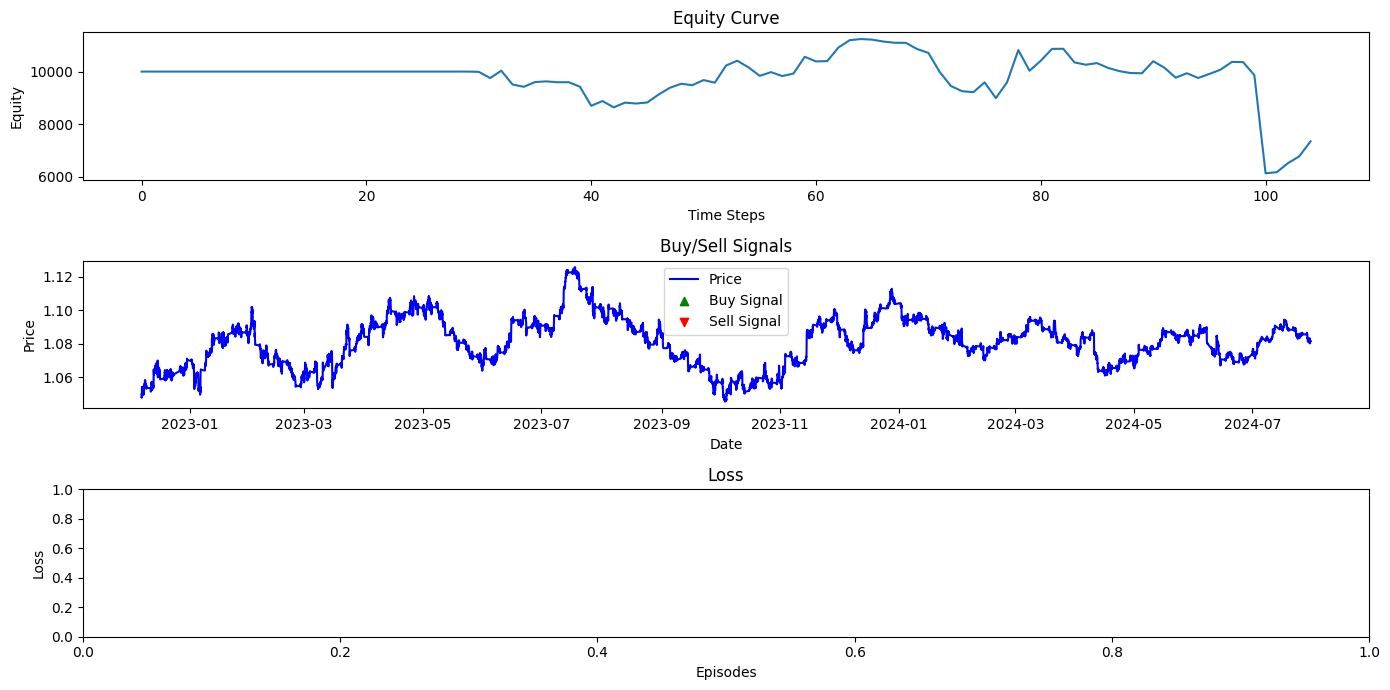

In [ ]:
plt.figure(figsize=(14, 7))

# Plot equity curve
plt.subplot(3, 1, 1)
plt.plot(env.equity_curve, label='Equity Curve')
plt.title('Equity Curve')
plt.xlabel('Time Steps')
plt.ylabel('Equity')

# Plot buy/sell signals
plt.subplot(3, 1, 2)
plt.plot(df.index, df['Close'], label='Price', color='blue')

buy_signals = [i for i, action in enumerate(env.actions) if action == 2]
sell_signals = [i for i, action in enumerate(env.actions) if action == 0]

buy_dates = df.index[buy_signals]
sell_dates = df.index[sell_signals]

plt.scatter(buy_dates, df.loc[buy_dates, 'Close'], marker='^', color='g', label='Buy Signal')
plt.scatter(sell_dates, df.loc[sell_dates, 'Close'], marker='v', color='r', label='Sell Signal')

plt.title('Buy/Sell Signals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

# Plot loss
plt.subplot(3, 1, 3)
# plt.plot(custom_callback.losses, label='Loss')  # If you have loss data
plt.title('Loss')
plt.xlabel('Episodes')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()


**###Check for NaN's in the data from the indicators - averages**

In [ ]:
!nvidia-smi


Thu Aug  1 07:10:23 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA L4                      Off | 00000000:00:03.0 Off |                    0 |
| N/A   52C    P0              29W /  72W |    261MiB / 23034MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

## Quick random test for the environment

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# Ensure the data is sorted by time
df = df.sort_values(by='Datetime')  # Replace 'Timestamp' with your actual time column

# Initialize the environment
env = TradingEnv(df)

# Reset the environment
state = env.reset()

# Run a single episode
done = False
while not done:
    action = env.action_space.sample()  # Random action
    next_state, reward, done, _ = env.step(action)
    env.render()

# Plot the results
print("Final Balance:", env.current_balance)
print("Final Position:", env.current_position)


NotImplementedError: 

In [ ]:
# prompt: count NaN in the df in each column and remove them

# Count NaNs in each column
nan_counts = df.isna().sum()
print(nan_counts)



Open               0
High               0
Low                0
Close              0
TickVolume         0
Bar Volume         0
EMA_4            143
EMA_1             20
EMA_2             54
EMA_3             88
SMA_1             49
SMA_2            199
RSI                8
MACD              25
MACD_Signal       33
Fast_EMA          12
Slow_EMA          47
EMA_Crossover      0
dtype: int64


In [ ]:

# Remove rows with NaNs
df.dropna(inplace=True)

# Check if any NaNs remain
print(df.isna().sum())

Open             0
High             0
Low              0
Close            0
TickVolume       0
Bar Volume       0
EMA_4            0
EMA_1            0
EMA_2            0
EMA_3            0
SMA_1            0
SMA_2            0
RSI              0
MACD             0
MACD_Signal      0
Fast_EMA         0
Slow_EMA         0
EMA_Crossover    0
dtype: int64


# INSTALL PACKAGES

In [ ]:
!pip install stable-baselines3
!pip install 'shimmy>=0.2.1'
!pip install 'gymnasium<0.30'

  Using cached gymnasium-1.0.0a2-py3-none-any.whl.metadata (10 kB)
Using cached gymnasium-1.0.0a2-py3-none-any.whl (954 kB)
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 0.29.1
    Uninstalling gymnasium-0.29.1:
      Successfully uninstalled gymnasium-0.29.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
stable-baselines3 2.3.2 requires gymnasium<0.30,>=0.28.1, but you have gymnasium 1.0.0a2 which is incompatible.
  Using cached gymnasium-0.29.1-py3-none-any.whl.metadata (10 kB)
Using cached gymnasium-0.29.1-py3-none-any.whl (953 kB)
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.0.0a2
    Uninstalling gymnasium-1.0.0a2:
      Successfully uninstalled gymnasium-1.0.0a2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the s

# **Train a DQN**

In [ ]:
from stable_baselines3 import DQN

# Initialize the custom logger callback
logger_callback = CustomLoggerCallback(logger_callback)

# Initialize the RL agent
env = TradingEnv(df)
model = DQN('MlpPolicy', env, verbose=1)

# Train the model with the callback
model.learn(total_timesteps=160000, callback=logger_callback)

# Save the model
model.save("dqn_trading_model")

# Retrieve the logged data
logs = logger_callback.get_logs()


# Plotting results
plt.figure(figsize=(14, 10))

# Plot training loss
plt.subplot(3, 1, 1)
plt.plot(logs["losses"], label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')

# Plot rewards
plt.subplot(3, 1, 2)
plt.plot(logs["rewards"], label='Rewards')
plt.title('Episode Rewards')
plt.xlabel('Episodes')
plt.ylabel('Reward')

# Plot episode lengths
plt.subplot(3, 1, 3)
plt.plot(logs["episode_lengths"], label='Episode Lengths')
plt.title('Episode Lengths')
plt.xlabel('Episodes')
plt.ylabel('Length')

plt.tight_layout()
plt.show()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


AttributeError: 'NoneType' object has no attribute 'get_stats'

In [ ]:
import pandas as pd
import numpy as np
import gym
from gym import spaces
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback
import matplotlib.pyplot as plt

# Custom Callback for logging
class CustomLoggerCallback(BaseCallback):
    def __init__(self, verbose=0):
        super(CustomLoggerCallback, self).__init__(verbose)
        self.rewards = []
        self.episode_lengths = []

    def _on_step(self) -> bool:
        if self.locals['infos']:
            info = self.locals['infos'][0]
            print("Info Dictionary:", info)  # Print info dictionary to inspect its structure
            if 'episode' in info.keys():
                print("Episode Data:", info['episode'])  # Print episode data to inspect its structure
                self.episode_lengths.append(info['episode'].get('length', 0))
                self.rewards.append(info['episode'].get('r', 0))
        return True

    def get_logs(self):
        return {
            "rewards": self.rewards,
            "episode_lengths": self.episode_lengths
        }


env = TradingEnv(df)

# Initialize the RL agent
model = DQN('MlpPolicy', env, verbose=1)

# Initialize the custom logger callback
logger_callback = CustomLoggerCallback()

# Train the model with the callback
model.learn(total_timesteps=160000, callback=logger_callback)

# Save the model
model.save("dqn_trading_model")

# Retrieve the logged data
logs = logger_callback.get_logs()

# Plotting results
plt.figure(figsize=(14, 10))

# Plot rewards
plt.subplot(2, 1, 1)
plt.plot(logs["rewards"], label='Rewards')
plt.title('Episode Rewards')
plt.xlabel('Episodes')
plt.ylabel('Reward')

# Plot episode lengths
plt.subplot(2, 1, 2)
plt.plot(logs["episode_lengths"], label='Episode Lengths')
plt.title('Episode Lengths')
plt.xlabel('Episodes')
plt.ylabel('Length')

plt.tight_layout()
plt.show()


Streaming output truncated to the last 5000 lines.
Info Dictionary: {'TimeLimit.truncated': False}
Info Dictionary: {'TimeLimit.truncated': False}
Info Dictionary: {'TimeLimit.truncated': False}
Info Dictionary: {'TimeLimit.truncated': False}
Info Dictionary: {'TimeLimit.truncated': False}
Info Dictionary: {'TimeLimit.truncated': False}
Info Dictionary: {'TimeLimit.truncated': False}
Info Dictionary: {'TimeLimit.truncated': False}
Info Dictionary: {'TimeLimit.truncated': False}
Info Dictionary: {'TimeLimit.truncated': False}
Info Dictionary: {'TimeLimit.truncated': False}
Info Dictionary: {'TimeLimit.truncated': False}
Info Dictionary: {'TimeLimit.truncated': False}
Info Dictionary: {'TimeLimit.truncated': False}
Info Dictionary: {'TimeLimit.truncated': False}
Info Dictionary: {'TimeLimit.truncated': False}
Info Dictionary: {'TimeLimit.truncated': False}
Info Dictionary: {'TimeLimit.truncated': False}
Info Dictionary: {'TimeLimit.truncated': False}
Info Dictionary: {'TimeLimit.truncate

KeyboardInterrupt: 

## Model Test

In [ ]:

model = DQN.load("dqn_trading_model")

# Testing the trained model
state = env.reset()
actions = []
equity_curve = []
done = False
while not done:
    action, _ = model.predict(state)
    next_state, reward, done, _ = env.step(action)
    actions.append(action)
    equity_curve.append(env.current_balance)
    state = next_state


FileNotFoundError: [Errno 2] No such file or directory: 'dqn_trading_model.zip'

NameError: name 'equity_curve' is not defined

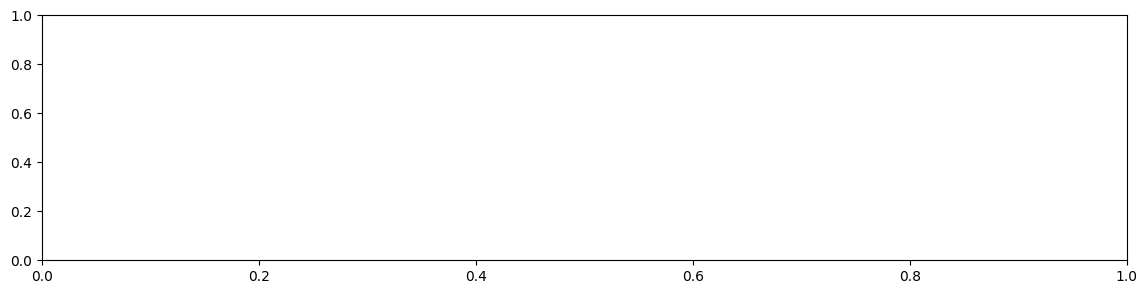

In [ ]:
import matplotlib.pyplot as plt

# Ensure 'Date' or timestamp column is properly set as index if needed
# df.set_index('Date', inplace=True)  # Uncomment this line if you need to set the index

# Example DataFrame structure
# df.index should be datetime or time index
# df['Close'] contains the price data

# Plotting results
plt.figure(figsize=(14, 7))

# Plot equity curve
plt.subplot(2, 1, 1)
plt.plot(equity_curve, label='Equity Curve')
plt.title('Equity Curve')
plt.xlabel('Time Steps')
plt.ylabel('Equity')

# Plot buy/sell signals
plt.subplot(2, 1, 2)
plt.plot(df.index, df['Close'], label='Price', color='blue')

# Aligning signals with the correct indices
buy_signals = [i for i, action in enumerate(actions) if action == 1]
sell_signals = [i for i, action in enumerate(actions) if action == 2]

# Convert indices to DatetimeIndex if they are integer positions
buy_dates = df.index[buy_signals]
sell_dates = df.index[sell_signals]

# Plotting buy/sell signals
plt.scatter(buy_dates, df.loc[buy_dates, 'Close'], marker='^', color='g', label='Buy Signal')
plt.scatter(sell_dates, df.loc[sell_dates, 'Close'], marker='v', color='r', label='Sell Signal')

plt.title('Buy/Sell Signals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

plt.tight_layout()
plt.show()


### ***Appendix - Older Environment Loading***

In [ ]:
class TradingEnv(gym.Env):
    def __init__(self, data):
        super(TradingEnv, self).__init__()

        self.data = data
        self.current_step = 0
        self.balance = 10000
        self.net_worth = self.balance
        self.positions = []
        self.max_steps = len(data) - 1

        self.action_space = spaces.Discrete(3)  # 0: Hold, 1: Buy, 2: Sell
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(len(data.columns),), dtype=np.float32)

        self.actions = []
        self.states = []

    def reset(self):
        self.current_step = 0
        self.balance = 10000
        self.net_worth = self.balance
        self.positions = []
        self.actions = []
        self.states = []
        return self._next_observation()

    def _next_observation(self):
        return self.data.iloc[self.current_step].values.astype(np.float32)

    def step(self, action):
        self.current_step += 1
        if self.current_step > self.max_steps:
            self.current_step = self.max_steps

        self.actions.append(action)
        self.states.append(self.data.iloc[self.current_step].values)

        current_price = self.data.iloc[self.current_step]['Close']
        if action == 1:  # Buy
            self.positions.append(current_price)
            self.balance -= current_price
        elif action == 2 and self.positions:  # Sell
            buy_price = self.positions.pop(0)
            self.balance += current_price

        self.net_worth = self.balance + sum(self.positions)

        done = self.current_step == self.max_steps

        # Ensure reward calculation does not result in NaN values
        reward = self.net_worth - self.balance
        reward = np.nan_to_num(reward)  # Replace NaN with 0

        return self._next_observation(), reward, done, {}

    def render(self, mode='human'):
        pass  # Implement rendering logic if needed

# Initialize environment
env = TradingEnv(df)


### ***Appendix - Older PPO model training***

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
-----------------------------
| time/              |      |
|    fps             | 512  |
|    iterations      | 1    |
|    time_elapsed    | 3    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 498          |
|    iterations           | 2            |
|    time_elapsed         | 8            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0058153546 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.1         |
|    explained_variance   | 0.000288     |
|    learning_rate        | 0.0003       |
|    loss                 | 1.92e+05     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00109     |
|    val

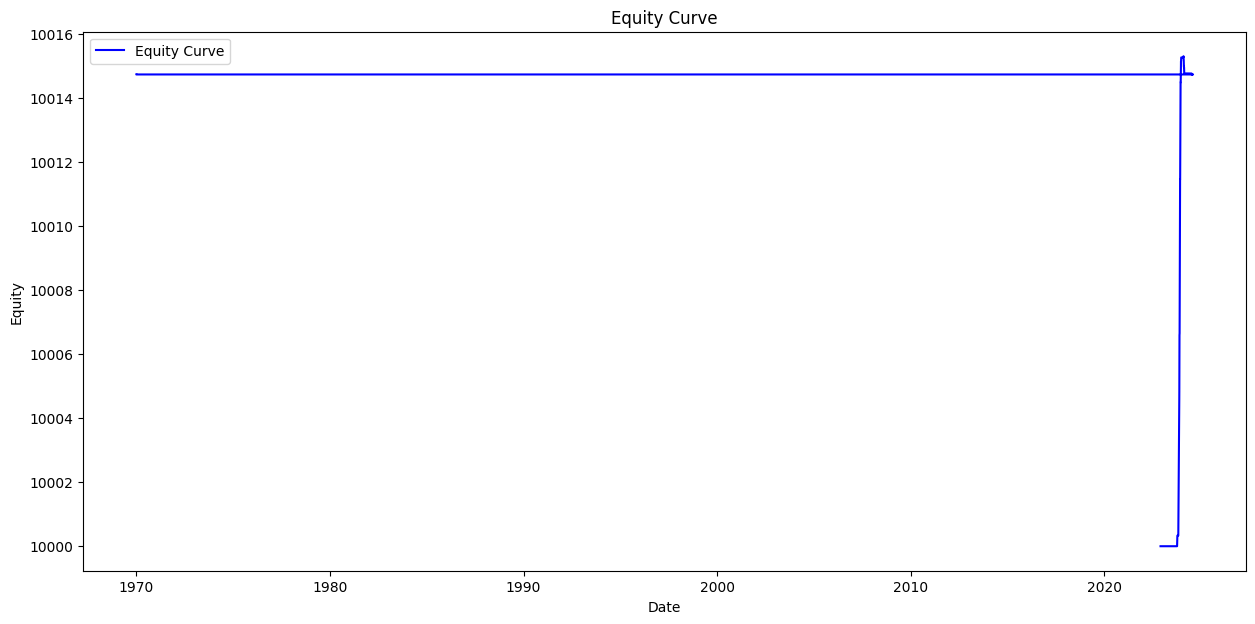

In [ ]:
from stable_baselines3 import PPO

# Train the model
model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=100000)

# Save the trained model
model.save("/mnt/data/trading_model")


# Initialize variables for evaluation
initial_balance = 10000
balance = initial_balance
net_worth = balance
positions = []
equity_curve = []

# Log Actions During Evaluation
obs = env.reset()
for i in range(len(df)):
    obs = obs.astype(np.float32)  # Ensure the observation is a NumPy array of floats
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, done, info = env.step(action)

    # Implement buy/sell logic based on action
    current_price = df.iloc[i]['Close']  # Use the correct column name
    if action == 1:  # Buy
        positions.append(current_price)
        balance -= current_price
    elif action == 2 and positions:  # Sell
        buy_price = positions.pop(0)
        balance += current_price

    net_worth = balance + sum(positions)
    equity_curve.append(net_worth)

    if done:
        break

# Convert equity curve to DataFrame for plotting
equity_df = pd.DataFrame(equity_curve, index=df.index[:len(equity_curve)], columns=['Equity'])

# Plot the equity curve
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.plot(equity_df.index, equity_df['Equity'], label='Equity Curve', color='blue')
plt.title('Equity Curve')
plt.xlabel('Date')
plt.ylabel('Equity')
plt.legend()
plt.show()

